In [1]:
import os
import numpy as np
from PIL import Image
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import scanpy as sc
import matplotlib.pyplot as plt

# === Define custom colormap ===
custom_cmap = LinearSegmentedColormap.from_list("custom_scale", [
    (0.0, "#454545"),
    (0.00000001, "#000000"),
    (0.10, "#000080"),
    (0.15, "#0000FF"),
    (0.30, "#8000FF"),
    (0.45, "#FF0000"),
    (0.60, "#FF8000"),
    (0.75, "#FFFF00"),
    (1.0, "#FFFFFF")
])

# === Parameters ===
input_folder = "/home/ajarrah/PhD_Thesis/chapter_4/h5ad_data/aad_1_20.h5ad"

aad_1 = sc.read_h5ad(input_folder)

In [2]:
aad_1

AnnData object with n_obs × n_vars = 45425 × 37
    obs: 'sample', 'y', 'x', 'x_um', 'y_um'
    obsm: 'spatial'

In [3]:
aad_1.obs

,sample,y,x,x_um,y_um
0,AAD_1,96,176,3520.0,1920.0
1,AAD_1,96,177,3540.0,1920.0
2,AAD_1,96,178,3560.0,1920.0
3,AAD_1,96,179,3580.0,1920.0
4,AAD_1,96,180,3600.0,1920.0
...,...,...,...,...,...
45420,AAD_1,337,217,4340.0,6740.0
45421,AAD_1,337,218,4360.0,6740.0
45422,AAD_1,337,219,4380.0,6740.0
45423,AAD_1,337,220,4400.0,6740.0


In [4]:
aad_1.var

""
gene
Zmat2
Zmat3
Zmat4
Zmat5
Zmiz1
Zmiz2
Zmpste24
Zmym2
Zmym3


In [5]:
custom_cmap = LinearSegmentedColormap.from_list("custom_scale", [
    (0.0, "#454545"),
    (0.00000001, "#000000"),
    (0.10, "#000080"),
    (0.15, "#0000FF"),
    (0.30, "#8000FF"),
    (0.45, "#FF0000"),
    (0.60, "#FF8000"),
    (0.75, "#FFFF00"),
    (1.0, "#FFFFFF")
])

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d

def show_feature_heatmap(adata, feature, pixel_size_um=60, cmap="viridis"):
    """
    Display a deterministic heatmap for a single feature from an AnnData object
    using spatial coordinates and a specified pixel size (in μm).

    Parameters
    ----------
    adata : AnnData
        AnnData object with spatial coordinates in `obsm['spatial']`
        or in `obs` columns 'x_um' and 'y_um'.
    feature : str
        Feature (variable) name to visualize.
    pixel_size_um : float, optional
        Pixel size in micrometers. Default is 60 μm.
    cmap : str or Colormap, optional
        Colormap for visualization. Default is 'viridis'.
    """

    # === Extract coordinates ===
    coords = adata.obsm['spatial'] if 'spatial' in adata.obsm else adata.obs[['x_um','y_um']].values
    x_um, y_um = coords[:,0], coords[:,1]

    # === Extract feature values ===
    values = adata[:, feature].X
    if hasattr(values, "toarray"):
        values = values.toarray().flatten()
    else:
        values = np.array(values).flatten()

    # === Define grid edges ===
    x_min, x_max = x_um.min(), x_um.max()
    y_min, y_max = y_um.min(), y_um.max()
    x_edges = np.arange(x_min, x_max + pixel_size_um, pixel_size_um)
    y_edges = np.arange(y_min, y_max + pixel_size_um, pixel_size_um)

    # === Compute mean per pixel using binned_statistic_2d ===
    heatmap, _, _, _ = binned_statistic_2d(
        x_um, y_um, values, statistic='mean', bins=[x_edges, y_edges]
    )

    # === Plot ===
    fig, ax = plt.subplots(figsize=(6,6))
    im = ax.imshow(
        heatmap.T,  # transpose to match orientation
        origin='lower',
        extent=[x_min, x_max, y_min, y_max],
        cmap=cmap,
        aspect='equal'
    )
    fig.colorbar(im, ax=ax, label=feature)
    ax.set_title(f"{feature} Intensity ({pixel_size_um} μm pixels)")
    ax.set_xlabel("X (μm)")
    ax.set_ylabel("Y (μm)")
    ax.invert_yaxis()  # match spatial transcriptomics convention
    plt.tight_layout()
    plt.show()

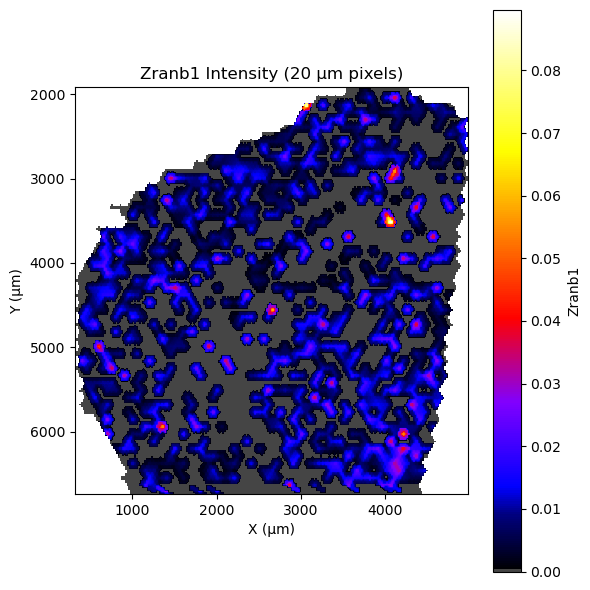

In [9]:
show_feature_heatmap(aad_1, feature="Zranb1", pixel_size_um=20, cmap=custom_cmap)


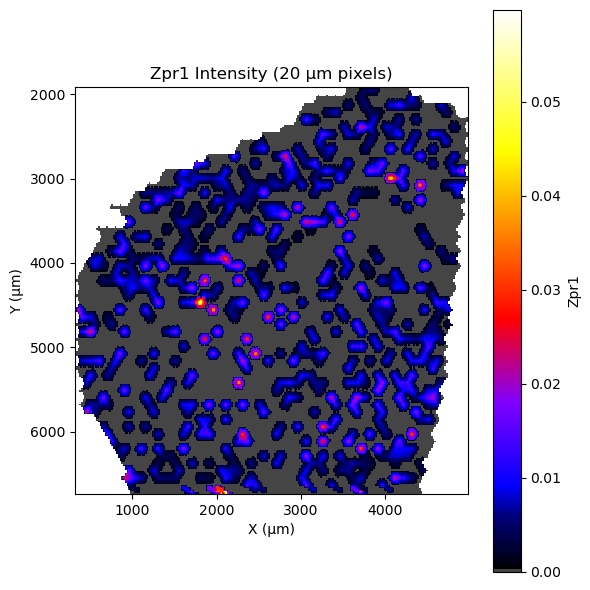

In [11]:
show_feature_heatmap(aad_1, feature="Zpr1", pixel_size_um=20, cmap=custom_cmap)
